# FL vs SFL — Non-IID One-Label-per-Client, 50 Rounds

This notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL / Design 1)** on MNIST under an extreme non-IID setting.

**Non-IID setup:** each client receives data from only one label. With MNIST, this notebook uses **10 clients** so that labels 0–9 are all represented.

After every global aggregation round, the notebook evaluates the global model on the full MNIST test set and stores one accuracy value per round for FL and SFL. With 50 rounds, the output table contains 50 accuracy values for FL and 50 accuracy values for SFL.

In [1]:
import os
import copy
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

## 1. Reproducibility and device setup

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Experiment settings and output folders

Run this notebook from the repository root folder: `Masters_project_SFL_servers/`.

In [59]:
# MNIST has 10 labels, so using 10 clients gives one label per client and still covers all classes.
NUM_CLIENTS = 10
ROUNDS = 50
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256
# LEARNING_RATE = 0.001

INITIAL_LR = 0.005
LR_DECAY = 0.98

def get_round_lr(round_id):
    return INITIAL_LR * (LR_DECAY ** (round_id - 1))

# Set to an integer such as 1000 for a quick test run.
# Set to None for the full one-label-per-client dataset.
MAX_SAMPLES_PER_CLIENT = None

RESULTS_CSV_DIR = "results/csv"
PLOTS_DIR = "results/plots"
WEIGHTS_DIR = "fl_sfl_noniid_one_label_weights"

os.makedirs(RESULTS_CSV_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print("CSV results will be saved to:", RESULTS_CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved to:", WEIGHTS_DIR)

CSV results will be saved to: results/csv
Plots will be saved to: results/plots
Weights will be saved to: fl_sfl_noniid_one_label_weights


## 3. Load MNIST dataset

In [60]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


## 4. Create non-IID client datasets

Each client receives samples from only one label.

Example: client 1 gets label 0, client 2 gets label 1, ..., client 10 gets label 9.

In [61]:
def get_targets(dataset):
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def create_one_label_client_subsets(dataset, num_clients: int, seed: int, max_samples_per_client=None):
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())

    if num_clients > len(unique_labels):
        raise ValueError("num_clients cannot be greater than the number of labels for one-label-per-client setup.")

    selected_labels = unique_labels[:num_clients]
    rng = np.random.default_rng(seed)

    subsets = []
    client_label_map = {}

    for client_id, label in enumerate(selected_labels):
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        if max_samples_per_client is not None:
            label_indices = label_indices[:max_samples_per_client]

        subsets.append(Subset(dataset, label_indices.tolist()))
        client_label_map[client_id] = label

    return subsets, client_label_map


client_subsets, client_label_map = create_one_label_client_subsets(
    train_dataset,
    num_clients=NUM_CLIENTS,
    seed=SEED,
    max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
)

for client_id, subset in enumerate(client_subsets):
    print(f"Client {client_id + 1}: label={client_label_map[client_id]}, samples={len(subset)}")

sample_counts = [len(subset) for subset in client_subsets]
print("Total samples used:", sum(sample_counts))

Client 1: label=0, samples=5923
Client 2: label=1, samples=6742
Client 3: label=2, samples=5958
Client 4: label=3, samples=6131
Client 5: label=4, samples=5842
Client 6: label=5, samples=5421
Client 7: label=6, samples=5918
Client 8: label=7, samples=6265
Client 9: label=8, samples=5851
Client 10: label=9, samples=5949
Total samples used: 60000


## 5. Data loaders

FL and SFL use the same deterministic batch order for each client and round.

In [62]:
def make_client_loader(client_id: int, round_id: int, method_tag: str):
    # Same seed formula for FL and SFL ensures identical batch order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

## 6. Models

In [ ]:
class FullModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()SGD
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)


class ClientModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        return self.relu2(self.fc2(x))


class ServerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)

## 7. State dictionary helpers

In [64]:
def get_state_dict(model: nn.Module):
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def full_to_server_state(full_state):
    return OrderedDict({
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
        "fc4.weight": full_state["fc4.weight"].clone(),
        "fc4.bias": full_state["fc4.bias"].clone(),
        "fc5.weight": full_state["fc5.weight"].clone(),
        "fc5.bias": full_state["fc5.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    full_state = OrderedDict()
    full_state["fc1.weight"] = client_state["fc1.weight"].clone()
    full_state["fc1.bias"] = client_state["fc1.bias"].clone()
    full_state["fc2.weight"] = client_state["fc2.weight"].clone()
    full_state["fc2.bias"] = client_state["fc2.bias"].clone()
    full_state["fc3.weight"] = server_state["fc3.weight"].clone()
    full_state["fc3.bias"] = server_state["fc3.bias"].clone()
    full_state["fc4.weight"] = server_state["fc4.weight"].clone()
    full_state["fc4.bias"] = server_state["fc4.bias"].clone()
    full_state["fc5.weight"] = server_state["fc5.weight"].clone()
    full_state["fc5.bias"] = server_state["fc5.bias"].clone()
    return full_state


def fedavg_state_dicts(state_dicts, sample_counts):
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            avg_tensor += state[key].float() * (n / total_samples)
        avg_state[key] = avg_tensor

    return avg_state


def l2_distance_state_dicts(state_a, state_b):
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5

## 8. Evaluation function

In [65]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

## 9. FL client training

In [66]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)

## 10. SFL Design 1 client training

Each client trains a client-side copy and an independent server-side copy for that round. Then both parts are aggregated with FedAvg.

In [67]:
def train_sfl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr)
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            smashed_data = client_model(x)
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)
            loss.backward()

            grad_to_client = smashed_data_detached.grad.clone()
            server_optimizer.step()

            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    return get_state_dict(client_model), get_state_dict(server_model)

## 11. Initialise FL and SFL from identical weights

In [68]:
set_seed(SEED)
initial_full_model = FullModel()
initial_full_state = get_state_dict(initial_full_model)

fl_global_state = copy.deepcopy(initial_full_state)
sfl_global_client_state = full_to_client_state(initial_full_state)
sfl_global_server_state = full_to_server_state(initial_full_state)

print("Initial FL and SFL states prepared from the same full model.")

Initial FL and SFL states prepared from the same full model.


## 12. Run 50 rounds and evaluate global accuracy after every round

In [69]:
results = []

for round_id in range(1, ROUNDS + 1):
    current_lr = get_round_lr(round_id)
    print(f"\n========== Round {round_id}/{ROUNDS} ==========")
    round_start_time = time.perf_counter()

    # -------------------------
    # FL local training
    # -------------------------
    fl_start_time = time.perf_counter()
    fl_client_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="fl")
        trained_state = train_fl_client(
            start_global_state=fl_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        fl_client_states.append(trained_state)

    fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)
    fl_time = time.perf_counter() - fl_start_time

    # Save only global model every round to avoid too many files.
    torch.save(fl_global_state, os.path.join(WEIGHTS_DIR, f"fl_round_{round_id:03d}_global.pth"))

    # -------------------------
    # SFL Design 1 local training
    # -------------------------
    sfl_start_time = time.perf_counter()
    sfl_client_side_states = []
    sfl_server_side_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="sfl")
        trained_client_state, trained_server_state = train_sfl_client_design1(
            start_client_state=sfl_global_client_state,
            start_server_state=sfl_global_server_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        sfl_client_side_states.append(trained_client_state)
        sfl_server_side_states.append(trained_server_state)

    sfl_global_client_state = fedavg_state_dicts(sfl_client_side_states, sample_counts)
    sfl_global_server_state = fedavg_state_dicts(sfl_server_side_states, sample_counts)
    sfl_global_full_state = split_to_full_state(sfl_global_client_state, sfl_global_server_state)
    sfl_time = time.perf_counter() - sfl_start_time

    torch.save(sfl_global_client_state, os.path.join(WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_client_side.pth"))
    torch.save(sfl_global_server_state, os.path.join(WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_server_side.pth"))
    torch.save(sfl_global_full_state, os.path.join(WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_full_reconstructed.pth"))

    # -------------------------
    # Evaluate global models after aggregation
    # -------------------------
    eval_start_time = time.perf_counter()

    fl_eval_model = FullModel().to(device)
    load_state_dict_to_model(fl_eval_model, fl_global_state)
    fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

    sfl_eval_model = FullModel().to(device)
    load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
    sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

    eval_time = time.perf_counter() - eval_start_time
    total_round_time = time.perf_counter() - round_start_time

    global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

    results.append({
        "round": round_id,
        "fl_test_loss": fl_test_loss,
        "fl_test_accuracy": fl_test_acc,
        "sfl_test_loss": sfl_test_loss,
        "sfl_test_accuracy": sfl_test_acc,
        "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
        "global_l2_distance_fl_vs_sfl": global_l2,
        "fl_time_sec": fl_time,
        "sfl_time_sec": sfl_time,
        "evaluation_time_sec": eval_time,
        "total_round_time_sec": total_round_time,
    })

    print(
        f"Round {round_id:03d} | "
        f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
        f"L2={global_l2:.6f}, "
        f"FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
    )

results_df = pd.DataFrame(results)
display(results_df)


========== Round 1/50 ==========
Round 001 | FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.0s, SFL time=3.2s

========== Round 2/50 ==========
Round 002 | FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.0s, SFL time=3.1s

========== Round 3/50 ==========
Round 003 | FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.1s, SFL time=3.3s

========== Round 4/50 ==========
Round 004 | FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.2s, SFL time=3.3s

========== Round 5/50 ==========
Round 005 | FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=2.9s, SFL time=3.3s

========== Round 6/50 ==========
Round 006 | FL acc=0.0881, SFL acc=0.0881, L2=0.000000, FL time=3.0s, SFL time=3.0s

========== Round 7/50 ==========
Round 007 | FL acc=0.0932, SFL acc=0.0932, L2=0.000000, FL time=2.9s, SFL time=3.0s

========== Round 8/50 ==========
Round 008 | FL acc=0.1103, SFL acc=0.1103, L2=0.000000, FL time=3.0s, SFL time=3.2s

========== Round 9/50 ==========
Round 009 | FL acc=0.1

,round,fl_test_loss,fl_test_accuracy,sfl_test_loss,sfl_test_accuracy,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec
0,1,2.311901,0.0892,2.311901,0.0892,0.0,0.0,3.030605,3.222074,0.654647,6.910545
1,2,2.310737,0.0892,2.310737,0.0892,0.0,0.0,2.955409,3.129050,0.658233,6.745731
2,3,2.309602,0.0892,2.309602,0.0892,0.0,0.0,3.068456,3.338023,0.654378,7.063998
3,4,2.308584,0.0892,2.308584,0.0892,0.0,0.0,3.232163,3.289642,0.655156,7.180057
4,5,2.307633,0.0892,2.307633,0.0892,0.0,0.0,2.875641,3.257349,0.636965,6.772895
5,6,2.306758,0.0881,2.306758,0.0881,0.0,0.0,2.954284,3.017038,0.638948,6.613171
6,7,2.306056,0.0932,2.306056,0.0932,0.0,0.0,2.922882,2.958955,0.653781,6.538500
7,8,2.305783,0.1103,2.305783,0.1103,0.0,0.0,3.004578,3.172988,0.648308,6.829094
8,9,2.307045,0.1028,2.307045,0.1028,0.0,0.0,2.895054,3.134585,0.655571,6.688324
9,10,2.317990,0.1028,2.317990,0.1028,0.0,0.0,3.008492,3.084561,0.638761,6.734773


## 13. Save CSV results

In [70]:
results_csv_path = os.path.join(RESULTS_CSV_DIR, "fl_vs_sfl_noniid_one_label_50_rounds.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved results CSV to:", results_csv_path)

Saved results CSV to: results/csv/fl_vs_sfl_noniid_one_label_50_rounds.csv


## 14. Plot FL vs SFL accuracy

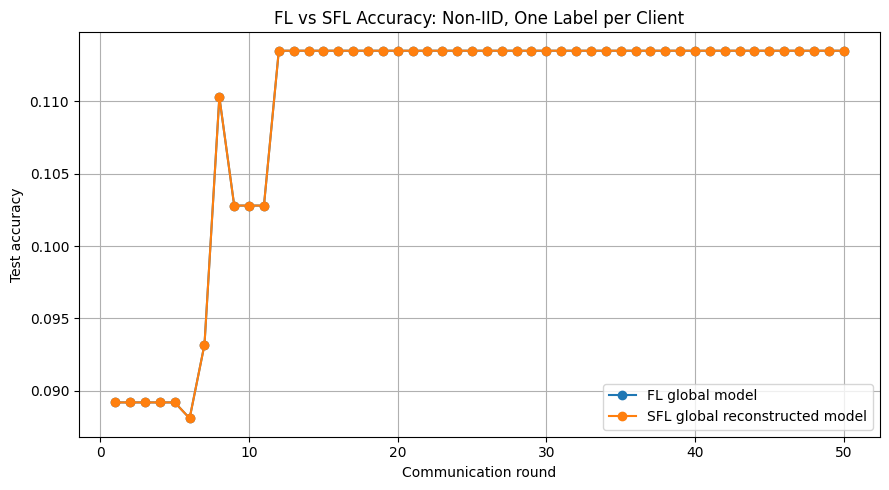

Saved accuracy plot to: results/plots/fl_vs_sfl_noniid_one_label_accuracy_50_rounds.png


In [71]:
accuracy_plot_path = os.path.join(PLOTS_DIR, "fl_vs_sfl_noniid_one_label_accuracy_50_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_accuracy"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_accuracy"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FL vs SFL Accuracy: Non-IID, One Label per Client")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=200)
plt.show()

print("Saved accuracy plot to:", accuracy_plot_path)

## 15. Plot FL vs SFL loss

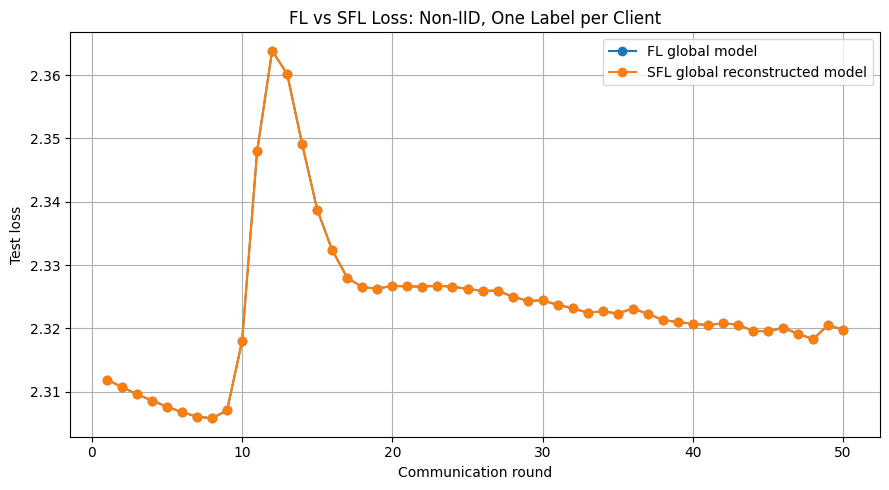

Saved loss plot to: results/plots/fl_vs_sfl_noniid_one_label_loss_50_rounds.png


In [72]:
loss_plot_path = os.path.join(PLOTS_DIR, "fl_vs_sfl_noniid_one_label_loss_50_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_loss"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_loss"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("FL vs SFL Loss: Non-IID, One Label per Client")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss plot to:", loss_plot_path)

## 16. Short report text for README / thesis notes

In [73]:
summary_text = f"""
Experiment: FL vs SFL under extreme non-IID data distribution.

Dataset: MNIST.
Clients: {NUM_CLIENTS}.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: {ROUNDS}.
Local epochs per client per round: {LOCAL_EPOCHS}.

The global model was evaluated after every aggregation round on the full MNIST test set.
The final FL accuracy was {results_df['fl_test_accuracy'].iloc[-1]:.4f}.
The final SFL accuracy was {results_df['sfl_test_accuracy'].iloc[-1]:.4f}.

The saved CSV file contains one row per communication round, giving 50 accuracy values for FL and 50 accuracy values for SFL.
"""

summary_path = os.path.join(RESULTS_CSV_DIR, "fl_vs_sfl_noniid_one_label_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved summary text to:", summary_path)


Experiment: FL vs SFL under extreme non-IID data distribution.

Dataset: MNIST.
Clients: 10.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: 50.
Local epochs per client per round: 1.

The global model was evaluated after every aggregation round on the full MNIST test set.
The final FL accuracy was 0.1135.
The final SFL accuracy was 0.1135.

The saved CSV file contains one row per communication round, giving 50 accuracy values for FL and 50 accuracy values for SFL.

Saved summary text to: results/csv/fl_vs_sfl_noniid_one_label_summary.txt
